In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, auc
from driver_genes.data.utils import compute_pred

import scanpy as sc
# set_style()
sns.set_theme(style='ticks')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['figure.dpi'] = 600
# Add these settings to avoid extra elements in the exported figure
plt.rcParams['figure.autolayout'] = True
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0
plt.rcParams['savefig.transparent'] = False


In [2]:
ad = sc.read_h5ad('../datasets/bian/preprocessed.h5ad')

padata = sc.read_h5ad('../results/macrophages/overlappedgenes-seed42/anndata/preprocessed_Monocyte.h5ad')
padata.X = padata.layers['dy']

In [3]:
padata.obsm['X_umap'] = padata.obs[['UMAP1', 'UMAP2']].values
mac_markers = {
    'M1': ['IL1B', 'IL6', 'TNF', 'CCL5'],
    'M2': ['ARG1', 'MRC1', 'TGFB1', 'STAT6', 'PPARG']
}
print(np.isin(mac_markers['M1'], ad.var_names))
print(np.isin(mac_markers['M2'], ad.var_names))
# print(np.isin(mac_markers['Migration'], radata.var_names))

[ True  True  True  True]
[ True  True  True  True  True]


In [4]:
sc.tl.score_genes(ad, gene_list=mac_markers['M2'], score_name='M2_score')
sc.tl.score_genes(ad, gene_list=mac_markers['M1'], score_name='M1_score')
padata.obs['M2_score'] = ad.obs['M2_score']
padata.obs['M1_score'] = ad.obs['M1_score']

In [5]:
padata.obs.to_parquet('data/macrophages_metadata.parquet')
padata.obsm['proba'].to_parquet('data/macrophages_proba_ours.parquet')


In [5]:
padata_macrophage = padata[
    padata.obs['cluster'].isin(['Mac_1', 'Mac_2', 'Mac_3', 'Mac_4']) &
    (padata.obs['UMAP1'] > (padata.obs['UMAP1'].mean() - 1.5 * padata.obs['UMAP1'].std()))
]


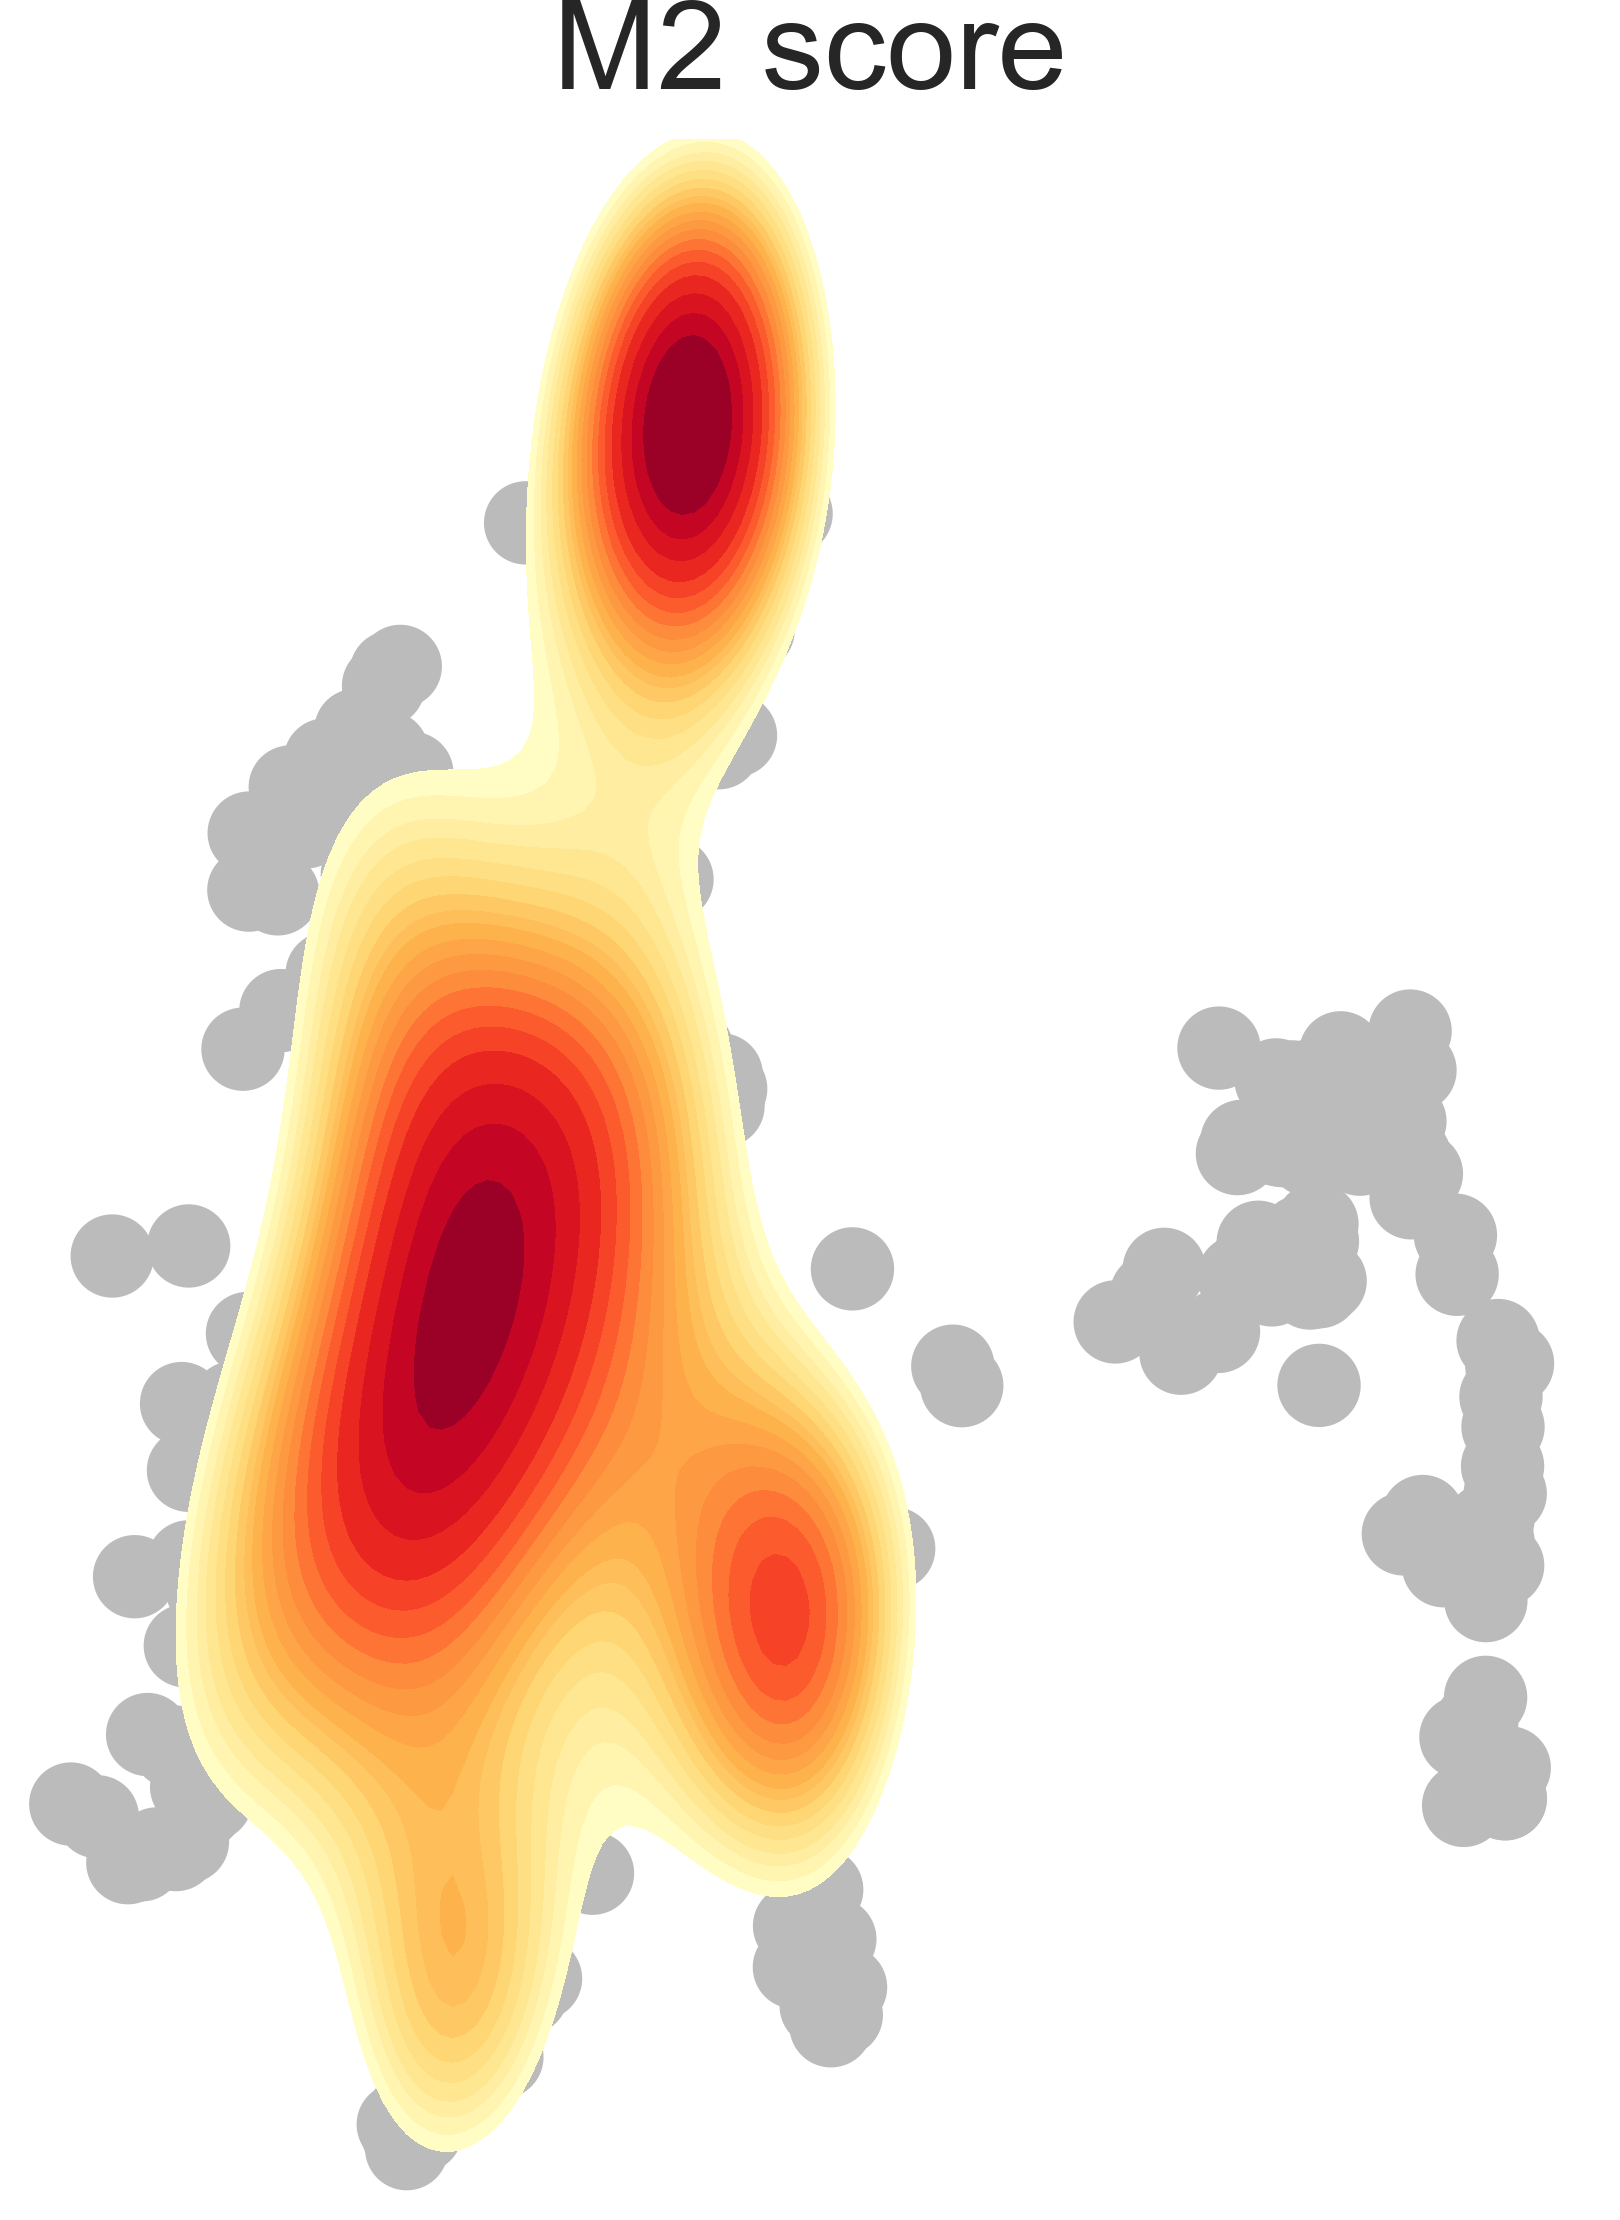

In [6]:
fig, ax = plt.subplots(figsize=(3, 4))
sc.pl.embedding(
    padata_macrophage, 
    basis='umap',
    color='cluster', 
    palette=['#bbbbbb'] * padata_macrophage.obs['cluster'].nunique(),
    frameon=False,
    show=False,
    size=400,
    wspace=0,
    ax=ax,
)
emb_umap = padata_macrophage.obsm['X_umap']
weights = padata_macrophage.obs['M2_score']
sns.kdeplot(
    x=emb_umap[:, 0],
    y=emb_umap[:, 1],
    weights=weights - weights.min(),
    thresh=0.4,
    fill=True,
    ax=ax,
    cmap='YlOrRd',
    # cut=10,
    levels=20,
)
ax.legend().remove()
ax.set_title('M2 score', fontsize=15)
ax.set_xlim(padata_macrophage.obsm['X_umap'][:, 0].min() * 0.9, padata_macrophage.obsm['X_umap'][:, 0].max() * 1.05)
ax.set_ylim(padata_macrophage.obsm['X_umap'][:, 1].min() * 1.05, padata_macrophage.obsm['X_umap'][:, 1].max() * 1.05)
plt.tight_layout()
# plt.savefig('../figures/4_macrophages_umap_m2_score.pdf', bbox_inches='tight')
plt.show()


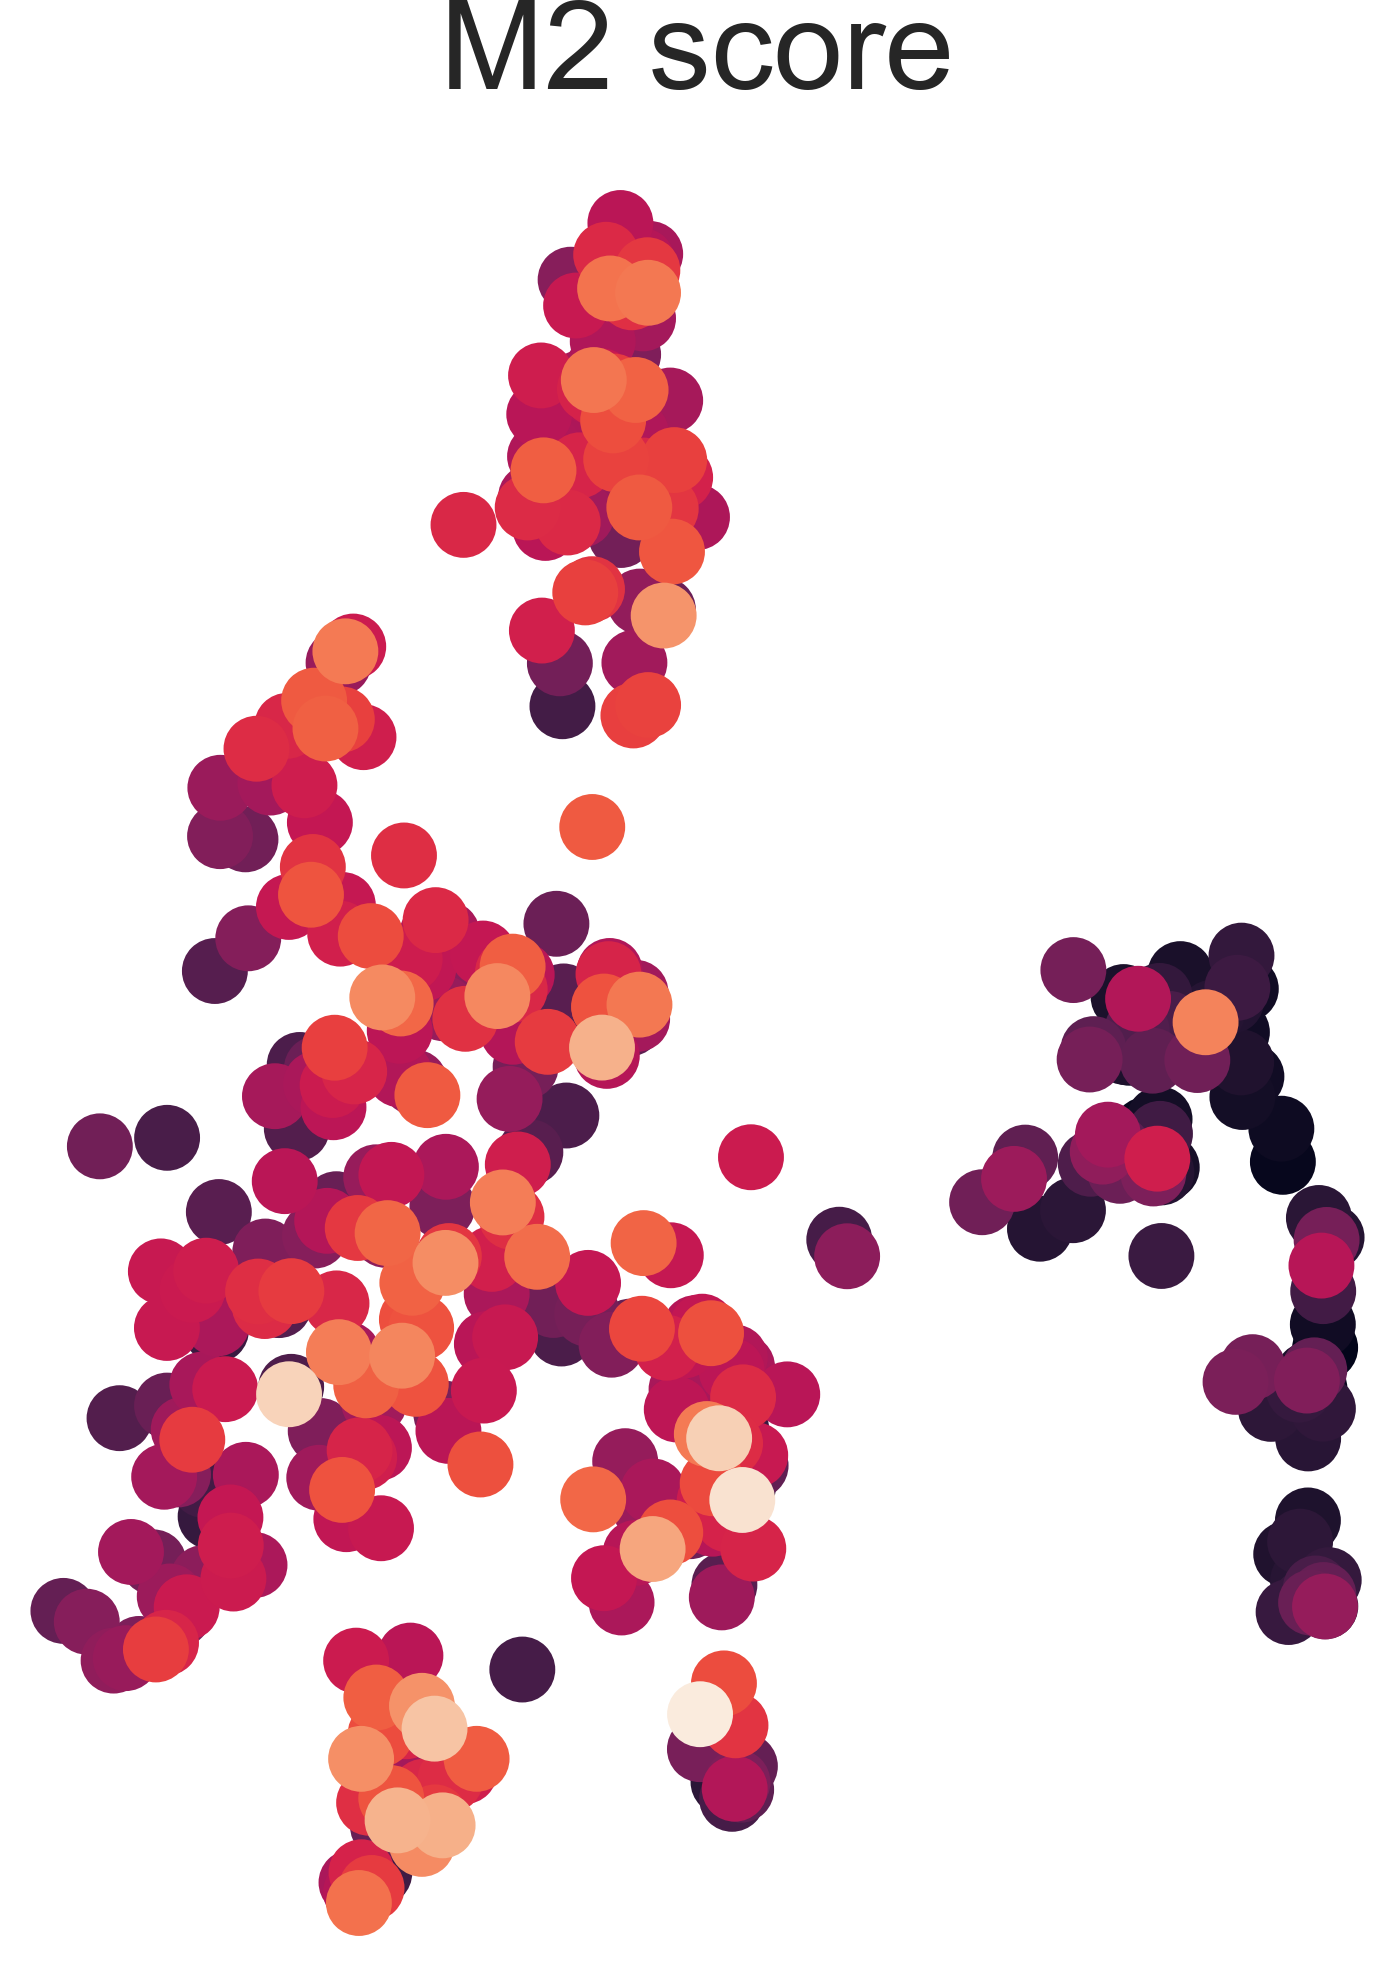

In [7]:
fig, ax = plt.subplots(figsize=(3, 4), gridspec_kw={'wspace': 0.25})
sc.pl.embedding(
    padata_macrophage, 
    basis='umap',
    color='M2_score',
    cmap='rocket', 
    frameon=False,
    show=False,
    size=250,
    ax=ax,
    # vmin=0,
)
ax.collections[0].colorbar.remove()
ax.set_title('M2 score', fontsize=15)
plt.tight_layout()
plt.savefig('../figures/4_macrophages_umap_m2_score_scatters.pdf', bbox_inches='tight')
plt.show()

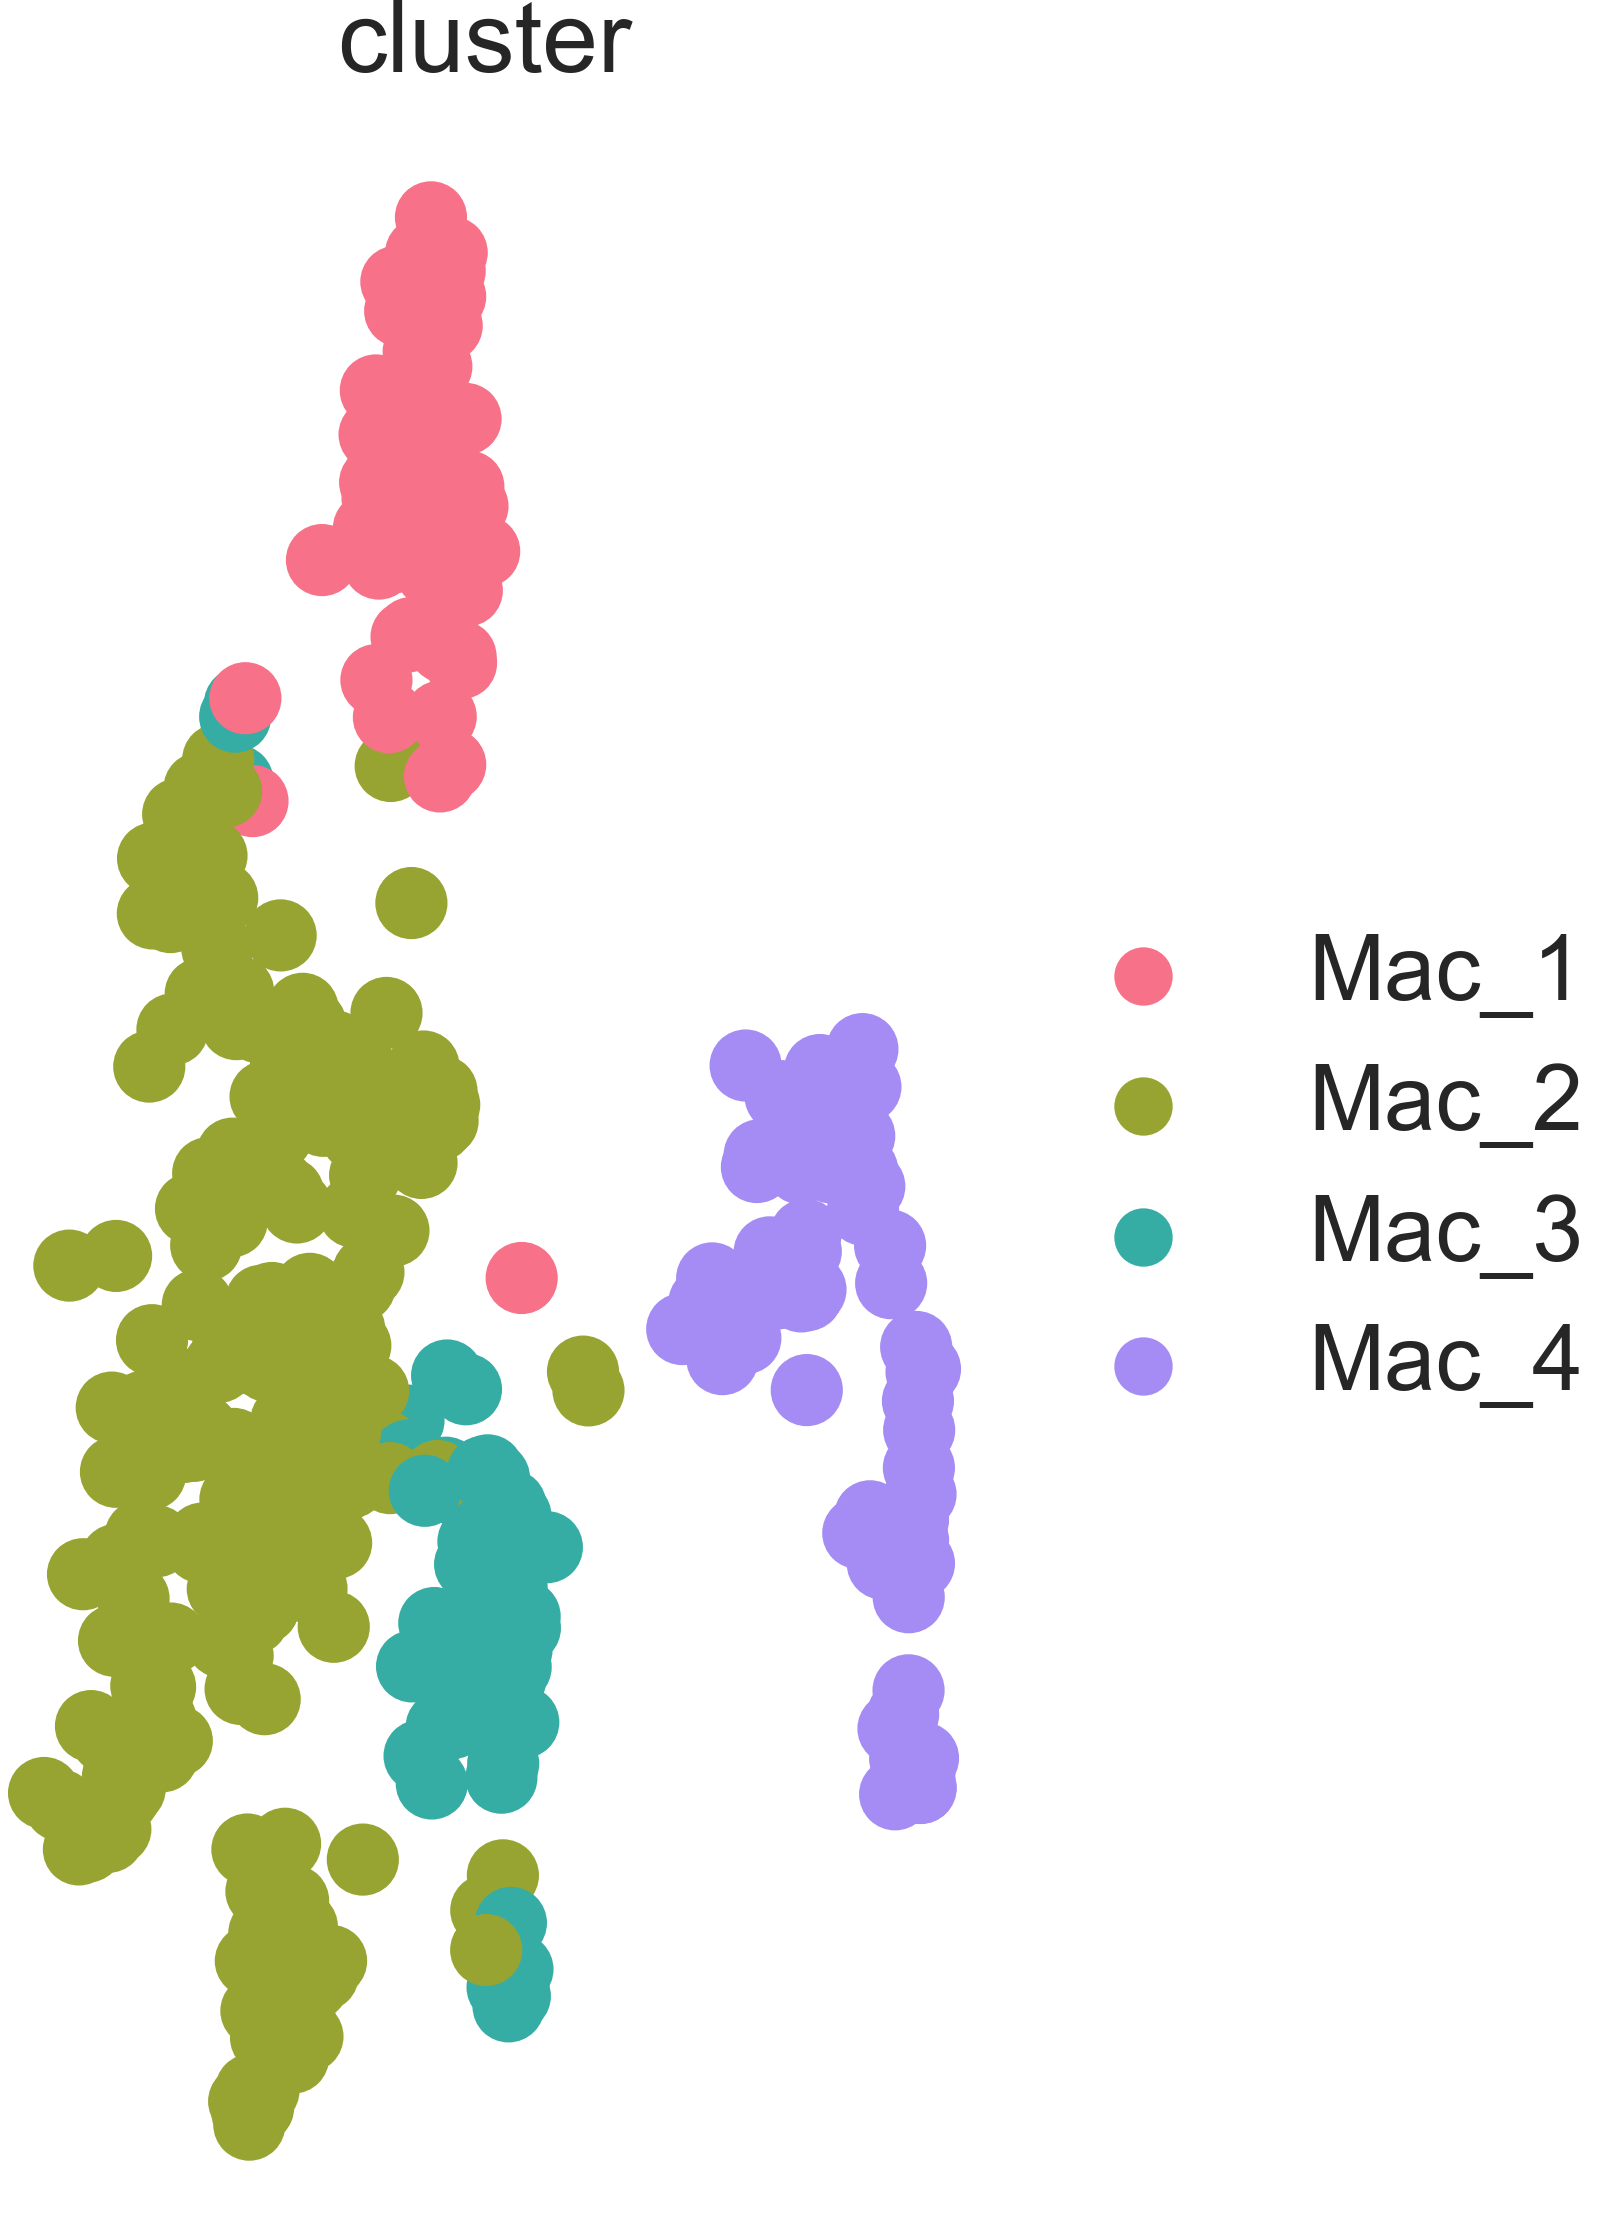

In [10]:
fig, ax = plt.subplots(figsize=(3, 4))
sc.pl.embedding(
    padata_macrophage, 
    basis='umap',
    color='cluster',
    palette=sns.color_palette('husl', 4),
    frameon=False,
    show=False,
    ax=ax,
)
fig.savefig('../figures/4_macrophages_umap_cluster.pdf', bbox_inches='tight')
fig.show()

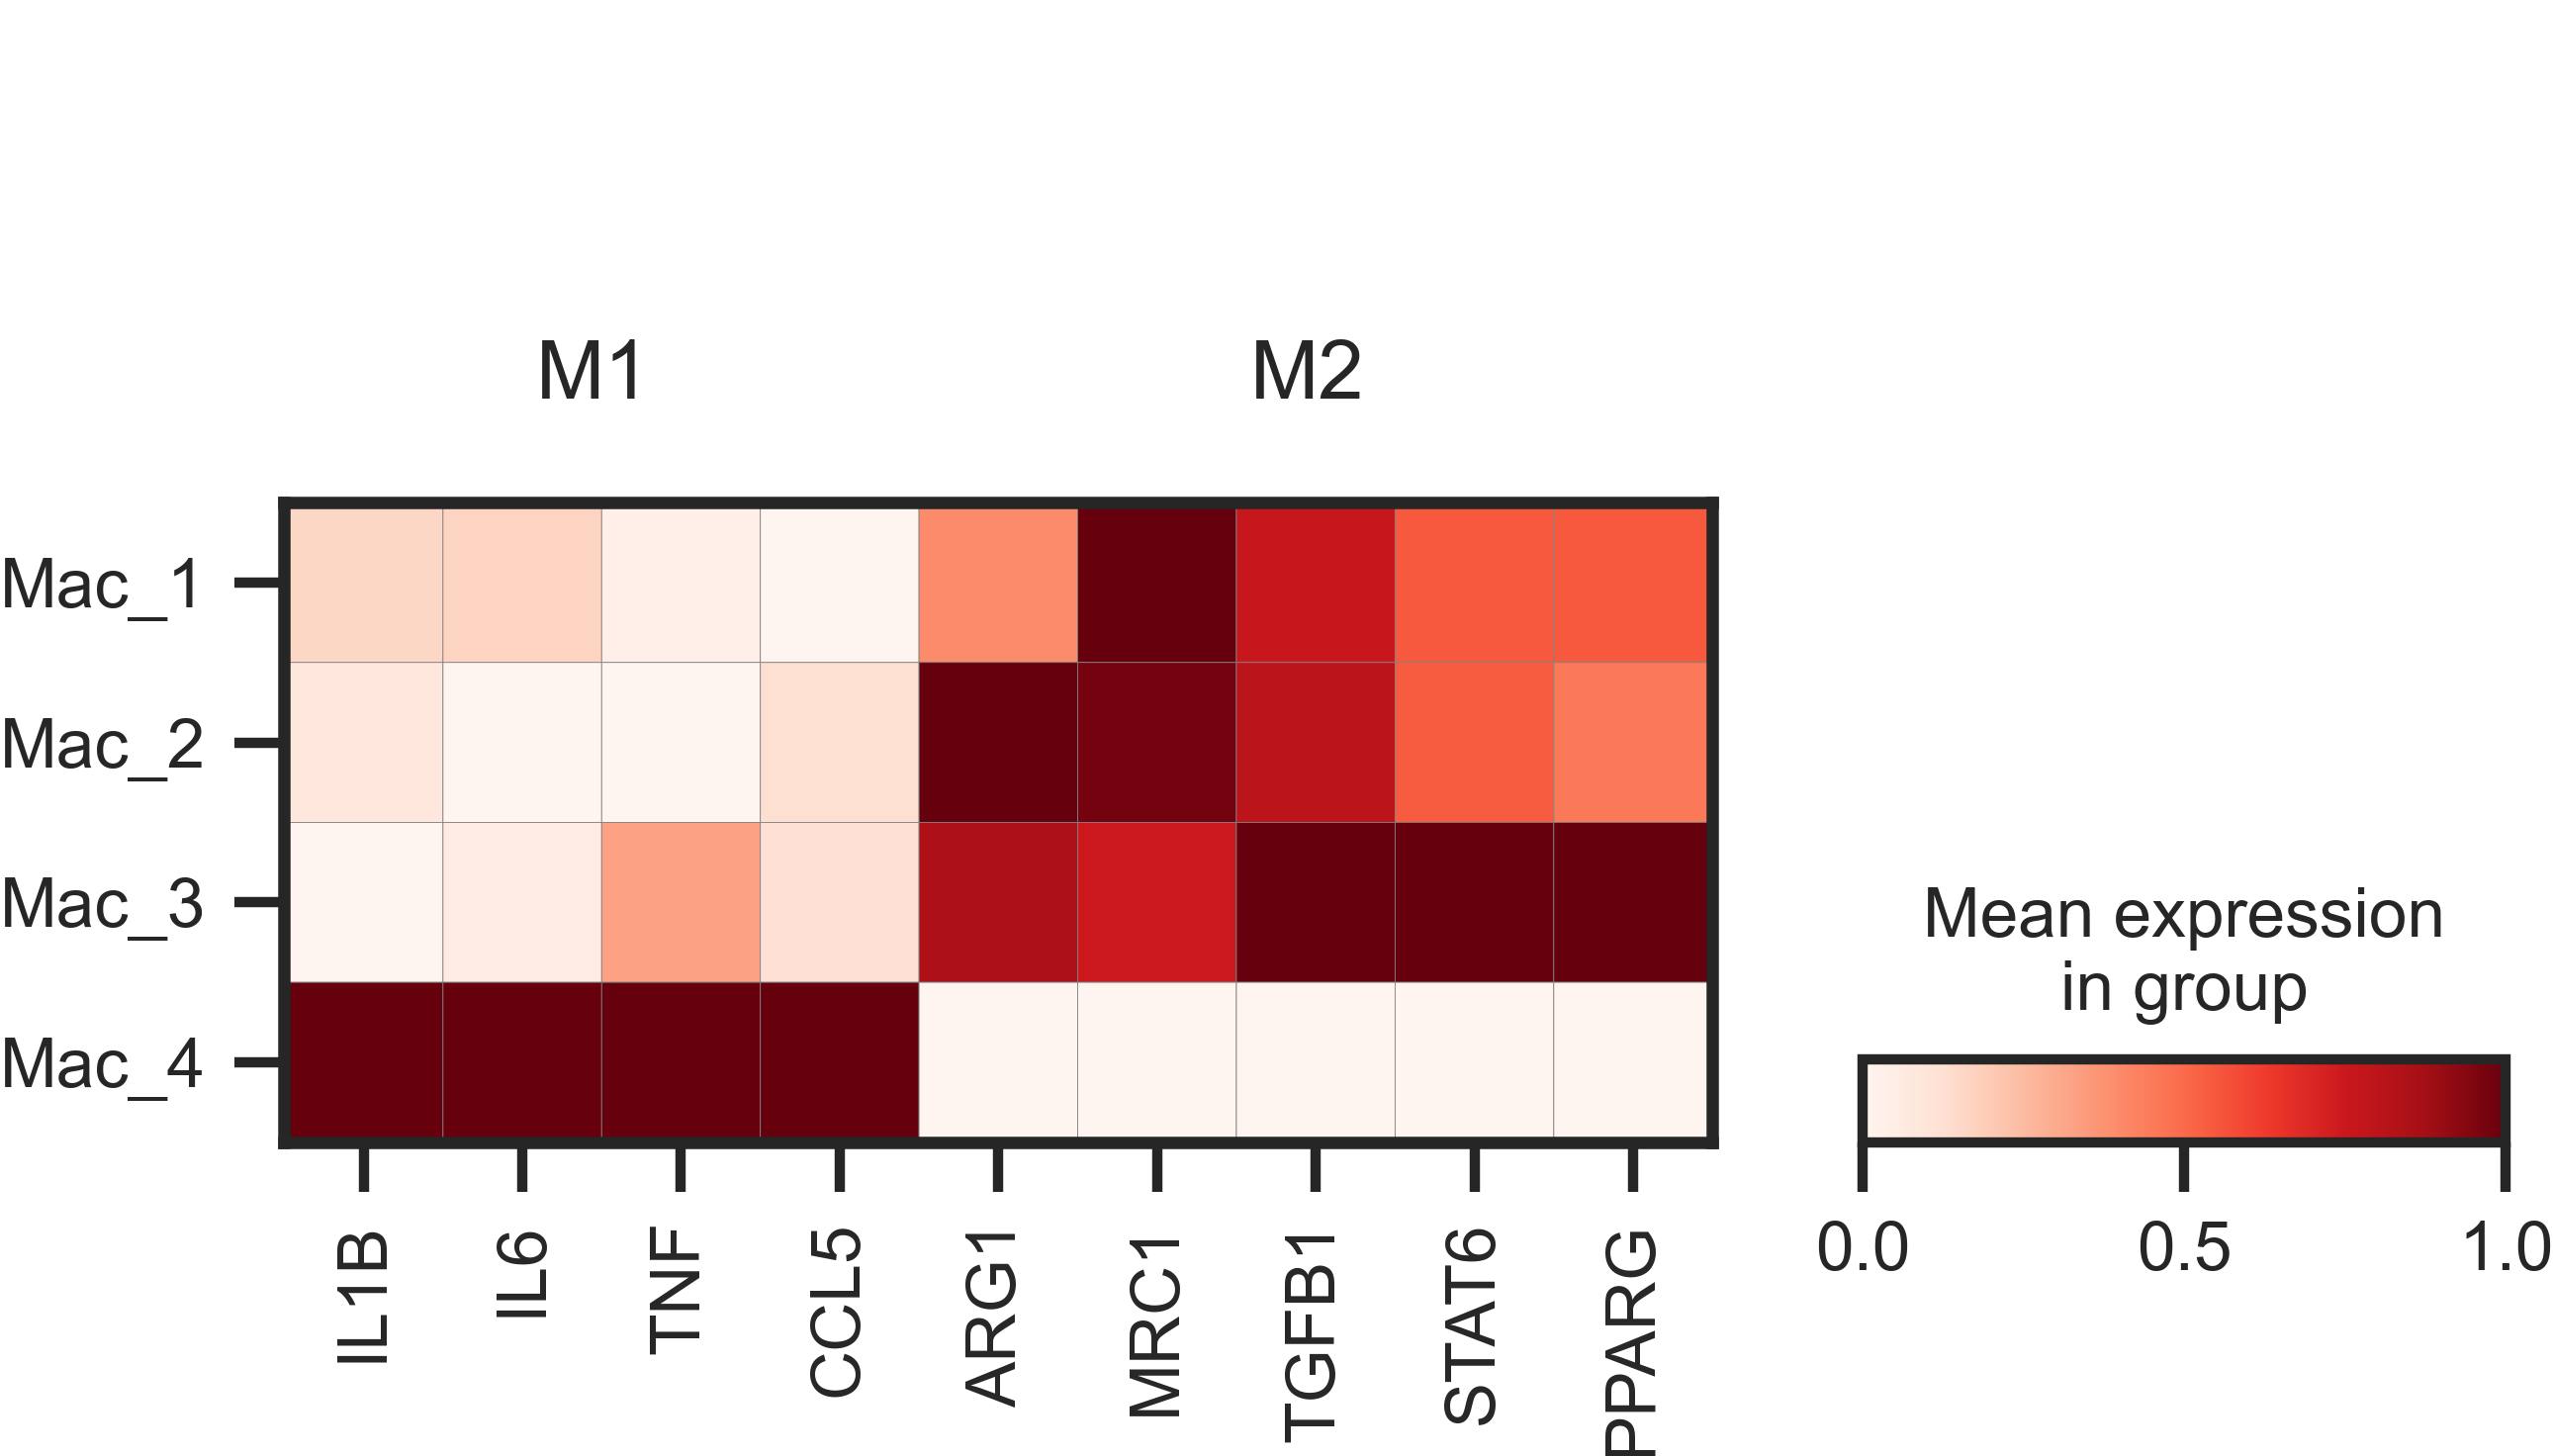

In [11]:
sc.pl.matrixplot(
    ad[ad.obs['cluster'].isin(['Mac_1', 'Mac_2', 'Mac_3', 'Mac_4'])], 
    var_names=mac_markers, 
    groupby='cluster', 
    standard_scale='var', 
    cmap='Reds', 
    show=False
)
plt.tight_layout()
plt.savefig('../figures/4_macrophages_matrixplot_markers.pdf', bbox_inches='tight')
plt.show()

In [14]:
order_full = ['Monocyte', 'Mac_1', 'Mac_2', 'Mac_3', 'Mac_4']
rename_dict = {
    'Monocyte': 'Monocyte',
    'Mac_1': 'Macrophage',
    'Mac_2': 'Macrophage',
    'Mac_3': 'Macrophage',
    'Mac_4': 'Macrophage',
}
padata.obsm['X_umap'] = padata.obs[['UMAP1', 'UMAP2']].values
padata.obs['subtype of interest'] = padata.obs['cluster'].map(lambda x: rename_dict.get(x, 'Other'))
padata.obs.head()

,Site,Stage,cluster,UMAP1,UMAP2,nGene,nUMI,perturbation,bc,M2_score,M1_score,subtype of interest
B1_TKR180900709_HT3YJCCXY_L6_sc3,Blood,CS17,Monocyte,0.870194,-4.707768,6202,447325,control,B1_TKR180900709_HT3YJCCXY_L6_sc3,0.065355,-0.154544,Monocyte
B1_TKR180900709_HT3YJCCXY_L6_sc67,Blood,CS17,Monocyte,1.787272,-0.315984,4726,165704,control,B1_TKR180900709_HT3YJCCXY_L6_sc67,-0.196408,0.313960,Monocyte
B8_TKR190100056_HY3F7CCXY_L2_sc68,Blood,CS15,Monocyte,2.466682,-1.021182,5666,413083,control,B8_TKR190100056_HY3F7CCXY_L2_sc68,0.219236,-0.101662,Monocyte
B9_FKDL190665150.1a_sc13,Blood,CS20,Monocyte,2.710891,-1.371606,6018,352823,control,B9_FKDL190665150.1a_sc13,0.072961,0.194466,Monocyte
B9_FKDL190665150.1a_sc15,Blood,CS20,Monocyte,3.047087,-1.336917,7294,754010,control,B9_FKDL190665150.1a_sc15,0.364177,-0.137195,Monocyte


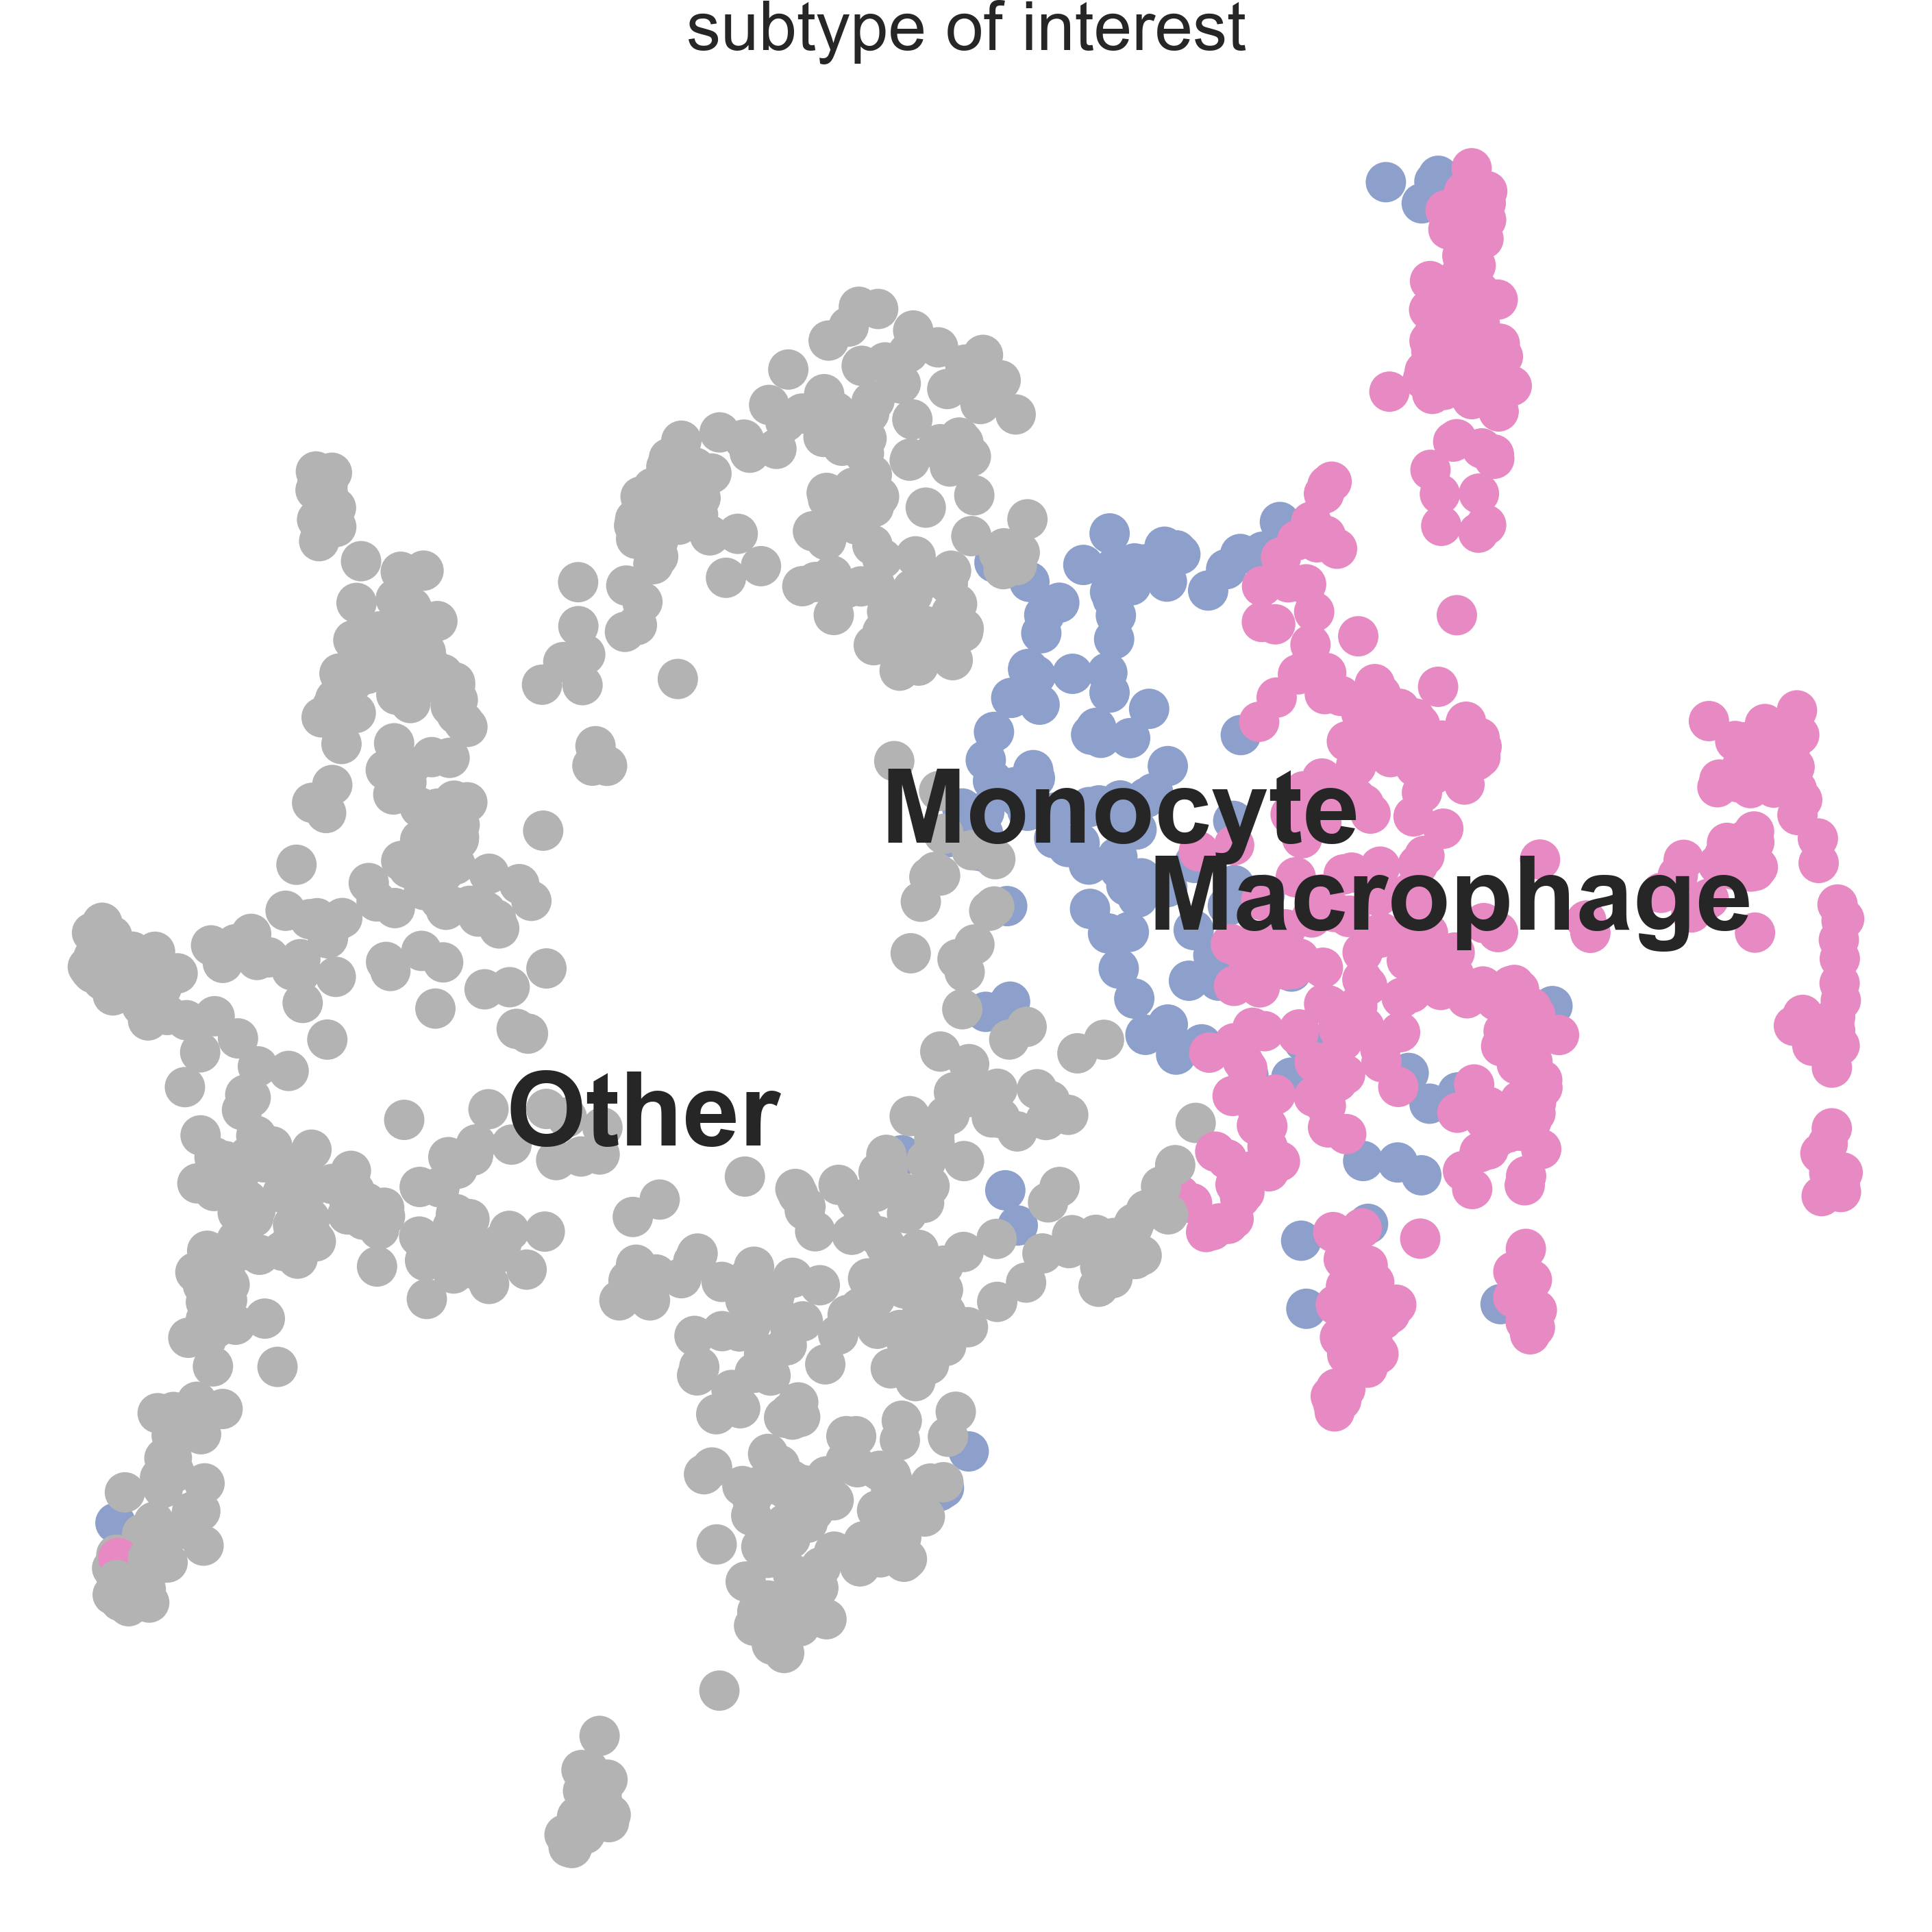

In [13]:
colors = [sns.color_palette('Set2', 8)[i] for i in [3, 2, 7]]
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(
    padata, color='subtype of interest', size=200, legend_loc='on data', ax=ax, show=False, 
    palette=colors, frameon=False,
    legend_fontsize=18,
)
if ax.collections:
    ax.collections[0].set_rasterized(True)
plt.tight_layout()
plt.savefig('../figures/4_macrophages_monocyte_umap_subtype.pdf', bbox_inches='tight')
plt.show()


In [16]:
padata_p = padata[(padata.obs['perturbation'] != 'control')].copy()

In [17]:
compute_pred(padata_p)

AnnData object with n_obs × n_vars = 1111 × 14511
    obs: 'Site', 'Stage', 'cluster', 'UMAP1', 'UMAP2', 'nGene', 'nUMI', 'perturbation', 'bc', 'M2_score', 'M1_score', 'subtype of interest', 'pred_perturbation'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pertgenes'
    obsm: 'latent', 'proba', 'shift', 'X_umap', 'rank', 'RelPos', 'logit'
    layers: 'X_hat', 'dy', 'raw'

In [18]:
padata_p.obsm['norm.proba'] = padata_p.obsm['logit'].transform(lambda x: np.exp(x) / np.sum(np.exp(x)), axis=1)

In [19]:
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr, mannwhitneyu

auc_df = pd.DataFrame(
    columns=[c for c in padata_p.obs['subtype of interest'].unique() if not pd.isna(c)],
    index=padata_p.obsm['proba'].columns
)
pval_df = pd.DataFrame(
    columns=[c for c in padata_p.obs['subtype of interest'].unique() if not pd.isna(c)],
    index=padata_p.obsm['proba'].columns,
)
for g in padata_p.obsm['proba'].columns:
    for c in padata_p.obs['subtype of interest'].unique():
        auc_df.loc[g, c] = roc_auc_score(
            padata_p.obs['subtype of interest'] == c, 
            padata_p.obsm['proba'][g]
        )
        pvals = (
            mannwhitneyu(
                padata_p.obsm['RelPos'][g][padata_p.obs['subtype of interest'] == c2], 
                padata_p.obsm['RelPos'][g][padata_p.obs['subtype of interest'] == c],
                alternative='less'
            )[1]
            for c2 in padata_p.obs['subtype of interest'].unique()
            if (c2 != c) and (not pd.isna(c2))
        )
        pval_df.loc[g, c] = np.nanmax(list(pvals))
# %%
# with pd.ExcelWriter('data/macrophage_auc_p_df.xlsx') as writer:
#     auc_df.to_excel(writer, sheet_name='AUC')
#     pval_df.to_excel(writer, sheet_name='pval')


In [20]:
driver_genes = ['ARPC2', 'STK11']

In [20]:
for gene in padata_p.obsm['proba'].columns:
    padata_p.obs[f'{gene} proba'] = padata_p.obsm['proba'][gene]
    padata_p.obs[f'{gene} RelPos'] = padata_p.obsm['RelPos'][gene]
    padata_p.obs[f'{gene} top 1'] = (padata_p.obsm['rank'][gene] == 1)
    padata_p.obs[f'{gene} top 5'] = (padata_p.obsm['rank'][gene] <= 5)
    padata_p.obs[f'{gene} Normalized proba'] = padata_p.obsm['norm.proba'][gene]


In [21]:
auc_df.loc[driver_genes]

,Other,Macrophage
ARPC2,0.041365,0.958635
STK11,0.126097,0.873903


In [22]:
pval_df.loc[driver_genes]


,Other,Macrophage
ARPC2,1.0,0.0
STK11,1.0,0.0


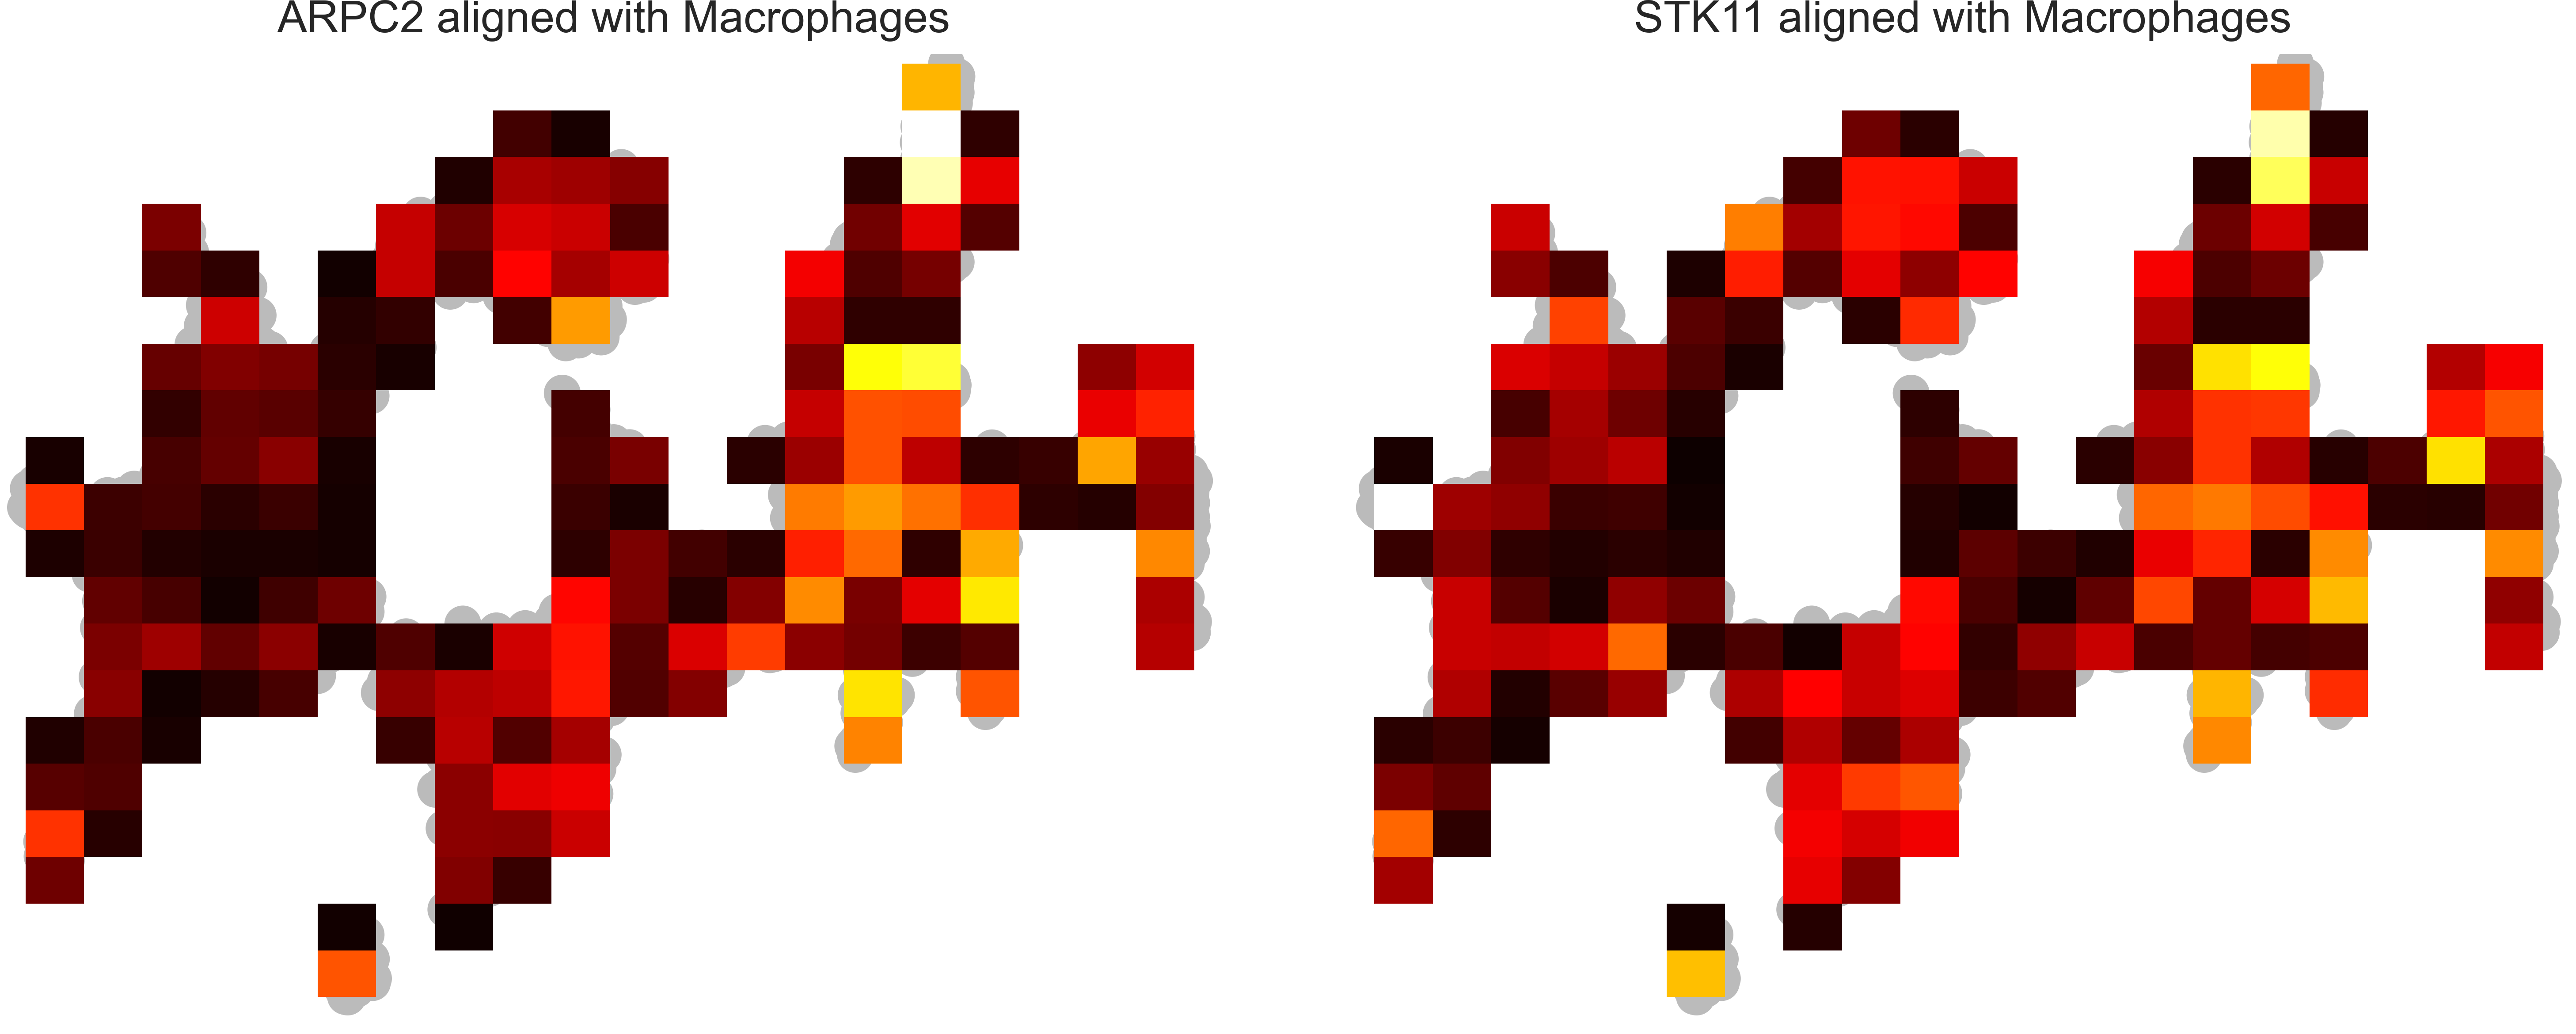

In [ ]:
axes = sc.pl.embedding(
    padata_p, 
    basis='umap',
    color=['cluster'] * len(driver_genes), 
    palette=['#bbbbbb'] * len(padata_p.obs['cluster'].unique()),
    frameon=False,
    size=400,
    show=False,
    wspace=0
)
emb_umap_all = padata_p.obsm['X_umap']
for ax, gene in zip(axes, driver_genes):
    if padata_p.obs[f'{gene} top 1'].nunique() > 1:
        emb_umap_subset = emb_umap_all[padata_p.obs[f'{gene} top 1']]
        sns.kdeplot(
            x=emb_umap_subset[:, 0],
            y=emb_umap_subset[:, 1],
            thresh=0.6 if gene == 'STK11' else 0.3,
            fill=True,
            ax=ax,
            cmap='YlOrRd',
            levels=20,
            cut=15,
        )
        ax.legend().remove()
        ax.set_title(f'{gene}', fontsize=14)
        ax.set_title(f'{gene} aligned with Macrophages')
        ax.set_xlim(padata_p.obsm['X_umap'][:, 0].min() * 1.05, padata_p.obsm['X_umap'][:, 0].max() * 1.05)
        ax.set_ylim(padata_p.obsm['X_umap'][:, 1].min() * 1.05, padata_p.obsm['X_umap'][:, 1].max() * 1.05)
plt.tight_layout()
plt.savefig('../figures/4_macrophages_monocyte_umap_top1.pdf', bbox_inches='tight')
plt.show()

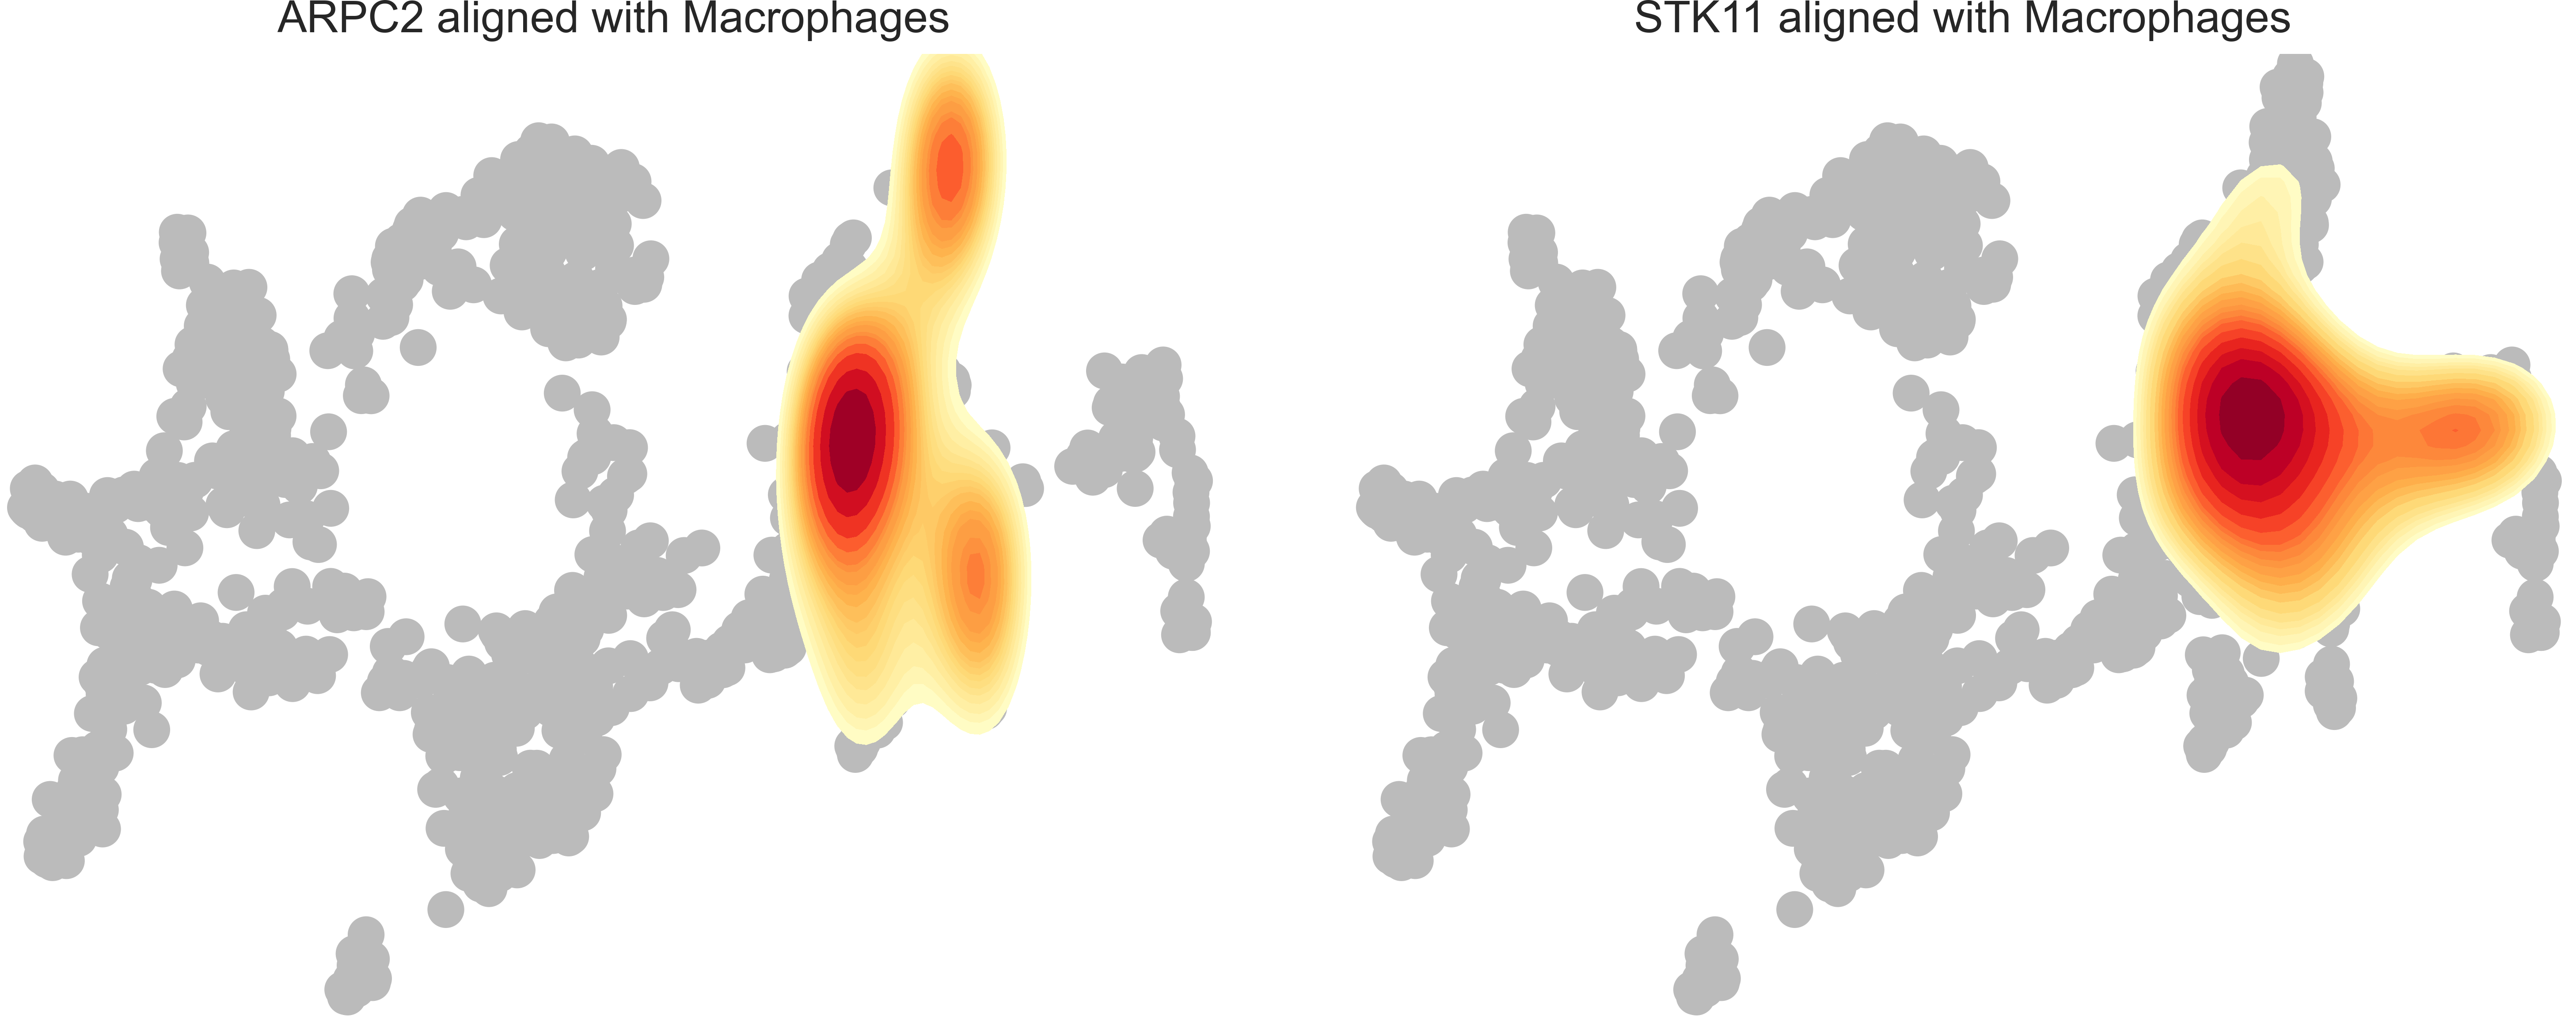

In [24]:
axes = sc.pl.embedding(
    padata_p, 
    basis='umap',
    color=['cluster'] * len(driver_genes), 
    palette=['#bbbbbb'] * len(padata_p.obs['cluster'].unique()),
    frameon=False,
    size=400,
    show=False,
    wspace=0
)
emb_umap_all = padata_p.obsm['X_umap']
for ax, gene in zip(axes, driver_genes):
    if padata_p.obs[f'{gene} top 1'].nunique() > 1:
        emb_umap_subset = emb_umap_all[padata_p.obs[f'{gene} top 1']]
        sns.kdeplot(
            x=emb_umap_subset[:, 0],
            y=emb_umap_subset[:, 1],
            thresh=0.6 if gene == 'STK11' else 0.3,
            fill=True,
            ax=ax,
            cmap='YlOrRd',
            levels=20,
            cut=15,
        )
        ax.legend().remove()
        ax.set_title(f'{gene}', fontsize=14)
        ax.set_title(f'{gene} aligned with Macrophages')
        ax.set_xlim(padata_p.obsm['X_umap'][:, 0].min() * 1.05, padata_p.obsm['X_umap'][:, 0].max() * 1.05)
        ax.set_ylim(padata_p.obsm['X_umap'][:, 1].min() * 1.05, padata_p.obsm['X_umap'][:, 1].max() * 1.05)
plt.tight_layout()
plt.savefig('../figures/4_macrophages_monocyte_umap_top1.pdf', bbox_inches='tight')
plt.show()